# Notebook 2: Phase 1 Baseline Model

**Sequential Transfer Learning for Medicinal Plant Identification**

---

## Purpose

Train the **baseline model** using ResNet50 transfer learning on Dataset 1.

**Dataset 1 Info:**
- 6 species: Arjun Leaf, Curry Leaf, Marsh Pennywort, Mint, Neem, Rubble Leaf
- ~1,380 original images

```
Phase 1: General Features (Dataset 1) <-- WE ARE HERE
    |
Phase 2: Regional Context (Dataset 2)
    |
Phase 3: Specialization (Datasets 4 & 5)
```

---

**Prerequisites:**
- Run `01_data_exploration.ipynb` first (downloads data to Google Drive)
- GPU required: Runtime -> Change runtime type -> GPU

**Output:**
- Model saved to Google Drive: `models/phase1_baseline.keras`

## 1. Mount Google Drive & Setup

In [ ]:
# Mount Google Drive
from google.colab import drive

print(">>> Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)
print(">>>>> Google Drive mounted!")

>>> Mounting Google Drive...
Mounted at /content/drive
>>>>> Google Drive mounted!


In [ ]:
# Import libraries
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f">>> GPU detected: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)  # avoid OOM errors
else:
    print("WARNING: No GPU! Go to Runtime -> Change runtime type -> GPU")

TensorFlow version: 2.19.0
>>> GPU detected: /physical_device:GPU:0


In [ ]:
# Configuration
IMG_SIZE = (224, 224)   # ResNet50 input size
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.2  # 80/20 train/val split
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Google Drive paths
DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

print(">>> Configuration loaded")
print(f"   Project: {PROJECT_DIR}")

>>> Configuration loaded
   Project: /content/drive/MyDrive/MedicinalPlant_Dissertation


## 2. Find Dataset 1

In [ ]:
def find_image_directory(base_dir):
    """Find the directory containing class folders with images."""
    if not os.path.exists(base_dir):
        return None

    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]  # skip hidden

        if not dirs:
            continue

        # Check if subdirectories contain images
        sample_dir = os.path.join(root, dirs[0])
        if os.path.isdir(sample_dir):
            sample_files = os.listdir(sample_dir)
            has_images = any(f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
                           for f in sample_files)
            if has_images:
                return root
    return None

# Find Dataset 1
print(">>> Finding Dataset 1...")

# try loading path from config first
config_path = os.path.join(PROJECT_DIR, "dataset_config.json")
DATASET1_PATH = None

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = json.load(f)
    DATASET1_PATH = config["dataset_paths"].get("dataset1")
    print(f"   Found via config file")

# fallback: search data directory
if not DATASET1_PATH or not os.path.exists(DATASET1_PATH):
    print("   Config not found, searching data directory...")
    dataset1_base = os.path.join(DATA_DIR, "dataset1")
    DATASET1_PATH = find_image_directory(dataset1_base)

# Check result
if DATASET1_PATH and os.path.exists(DATASET1_PATH):
    print(f"\n>>>>> Dataset 1 found!")
    print(f"   Path: {DATASET1_PATH}")

    # Count classes
    classes = [d for d in os.listdir(DATASET1_PATH)
               if os.path.isdir(os.path.join(DATASET1_PATH, d)) and not d.startswith('.')]
    print(f"   Classes: {len(classes)}")
    print(f"   Names: {classes}")
else:
    raise FileNotFoundError(
        "Dataset 1 not found!\n\n"
        "Please run 01_data_exploration.ipynb first to download the datasets.\n"
        f"Expected location: {os.path.join(DATA_DIR, 'dataset1')}"
    )

>>> Finding Dataset 1...
   Found via config file

>>>>> Dataset 1 found!
   Path: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset1/Medicinal Plant Identification Dataset/Augmented Images
   Classes: 6
   Names: ['Arjun Leaf', 'Curry Leaf', 'Marsh Pennywort Leaf', 'Mint Leaf', 'Neem Leaf', 'Rubble Leaf']


In [ ]:
# Load training dataset
print(">>> Loading Dataset 1 (6 species)...")
print("   Species: Arjun, Curry, Marsh Pennywort, Mint, Neem, Rubble\n")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET1_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET1_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

print(f">>>>> Dataset loaded!")
print(f"   Classes: {NUM_CLASSES}")
print(f"   Class names: {class_names}")

>>> Loading Dataset 1 (6 species)...
   Species: Arjun, Curry, Marsh Pennywort, Mint, Neem, Rubble

Found 7514 files belonging to 6 classes.
Using 6012 files for training.
Found 7514 files belonging to 6 classes.
Using 1502 files for validation.
>>>>> Dataset loaded!
   Classes: 6
   Class names: ['Arjun Leaf', 'Curry Leaf', 'Marsh Pennywort Leaf', 'Mint Leaf', 'Neem Leaf', 'Rubble Leaf']


## 3. Preprocessing

In [ ]:
# Normalization and augmentation
normalization = layers.Rescaling(1./255)  # scale pixel values to [0,1]

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# Apply normalization to both sets
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.map(lambda x, y: (normalization(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization(x), y))

# cache and prefetch for speed
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print(">>> Preprocessing ready")

>>> Preprocessing ready


## 4. Build ResNet50 Model

In [ ]:
# Load pre-trained ResNet50 (ImageNet weights)
print(">>> Loading ResNet50 (pre-trained on ImageNet)...")

base_model = ResNet50(
    weights='imagenet',
    include_top=False,          # remove the top classification layer
    input_shape=(224, 224, 3)
)

# Freeze base model layers so we only train our new head
base_model.trainable = False

print(f">>>>> ResNet50 loaded ({len(base_model.layers)} layers, frozen)")

>>> Loading ResNet50 (pre-trained on ImageNet)...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
>>>>> ResNet50 loaded (175 layers, frozen)


In [ ]:
# Build complete model
model = keras.Sequential([
    keras.Input(shape=(224, 224, 3)),
    data_augmentation,          # augmentation on-the-fly
    base_model,                 # frozen ResNet50 feature extractor
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.5),        # regularization
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')  # output layer
], name="phase1_baseline")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(">>> Model built and compiled")
model.summary()

>>> Model built and compiled


Model: "phase1_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,014 (92.02 MB)

 Trainable params: 530,694 (2.02 MB)

 Non-trainable params: 23,592,320 (90.00 MB)

## 5. Train Model

In [ ]:
# Callbacks - MODEL SAVED TO GOOGLE DRIVE
MODEL_PATH = os.path.join(MODEL_DIR, "phase1_baseline.keras")

callbacks = [
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

print(f">>> Model will be saved to Google Drive:")
print(f"   {MODEL_PATH}")

>>> Model will be saved to Google Drive:
   /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase1_baseline.keras


In [ ]:
# Train the model
print("\n" + "="*50)
print(">>>>> STARTING PHASE 1 TRAINING")
print("="*50)
print(f"Dataset: Dataset 1 ({NUM_CLASSES} species)")
print(f"Epochs: {EPOCHS} (with early stopping)")
print("="*50 + "\n")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*50)
print(">>>>> TRAINING COMPLETE!")
print("="*50)


>>>>> STARTING PHASE 1 TRAINING
Dataset: Dataset 1 (6 species)
Epochs: 30 (with early stopping)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.4952 - loss: 1.4746 
Epoch 1: val_accuracy improved from -inf to 0.22304, saving model to /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase1_baseline.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 2480s 13s/step - accuracy: 0.4958 - loss: 1.4725 - val_accuracy: 0.2230 - val_loss: 2.2011 - learning_rate: 0.0010
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.6995 - loss: 0.8109
Epoch 2: val_accuracy improved from 0.22304 to 0.48602, saving model to /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase1_baseline.keras
188/188 ━━━━━━━━━━━━━━━━━━━━ 35s 185ms/step - accuracy: 0.6996 - loss: 0.8107 - val_accuracy: 0.4860 - val_loss: 1.1008 - learning_rate: 0.0010
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.7367 - loss: 0.6782
Epoch 3: val_accuracy improved from 0.48602 to 0.7

## 6. Results

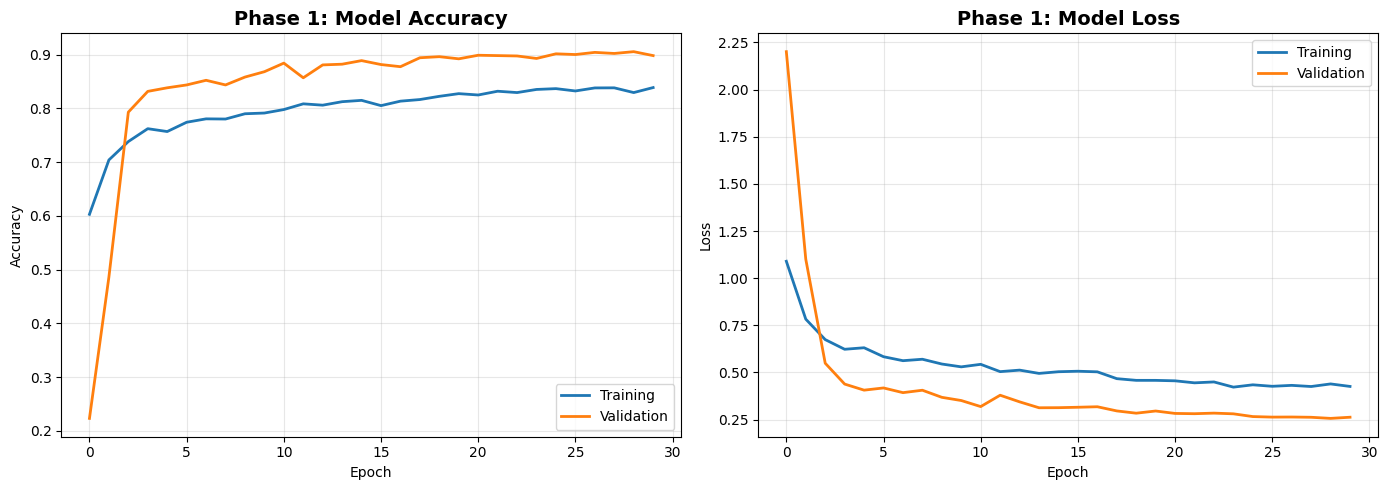

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Phase 1: Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Phase 1: Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'phase1_training_curves.png'), dpi=150)
plt.show()

In [ ]:
# Final evaluation on validation set
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=0)

print(">>> Final Results")
print("=" * 40)
print(f"   Validation Accuracy: {val_accuracy*100:.1f}%")
print(f"   Validation Loss: {val_loss:.4f}")
print("=" * 40)

>>> Final Results
   Validation Accuracy: 90.5%
   Validation Loss: 0.2565


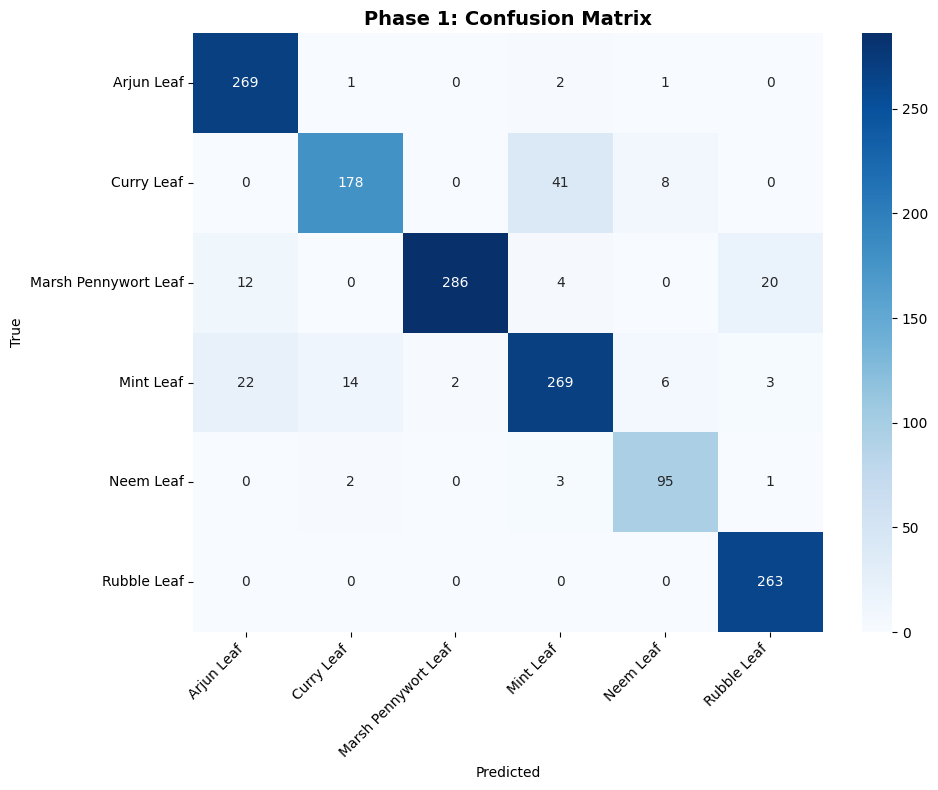

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true, y_pred = [], []
for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Phase 1: Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'phase1_confusion_matrix.png'), dpi=150)
plt.show()

In [ ]:
# Classification report - shows precision, recall, f1 per class
print(">>> Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

>>> Classification Report
                      precision    recall  f1-score   support

          Arjun Leaf       0.89      0.99      0.93       273
          Curry Leaf       0.91      0.78      0.84       227
Marsh Pennywort Leaf       0.99      0.89      0.94       322
           Mint Leaf       0.84      0.85      0.85       316
           Neem Leaf       0.86      0.94      0.90       101
         Rubble Leaf       0.92      1.00      0.96       263

            accuracy                           0.91      1502
           macro avg       0.90      0.91      0.90      1502
        weighted avg       0.91      0.91      0.90      1502



## 7. Save Model & Artifacts

In [ ]:
# Save model to Google Drive
model.save(MODEL_PATH)
print(f">>>>> Model saved: {MODEL_PATH}")

# Save class names for later use
with open(os.path.join(MODEL_DIR, "phase1_class_names.json"), 'w') as f:
    json.dump(class_names, f)

# Save training history
with open(os.path.join(MODEL_DIR, "phase1_history.json"), 'w') as f:
    history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    json.dump(history_dict, f)

# Save dataset path so Phase 2 can find it
config_path = os.path.join(PROJECT_DIR, "dataset_config.json")
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        existing_config = json.load(f)
    existing_config["dataset_paths"]["dataset1"] = DATASET1_PATH
    config = existing_config
else:
    config = {"dataset_paths": {"dataset1": DATASET1_PATH}}

with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(">>>>> All artifacts saved to Google Drive")
print(f"\nFiles saved:")
print(f"   - {MODEL_PATH}")
print(f"   - phase1_class_names.json")
print(f"   - phase1_history.json")
print(f"   - dataset_config.json")

>>>>> Model saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase1_baseline.keras
>>>>> All artifacts saved to Google Drive

Files saved:
   - /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase1_baseline.keras
   - phase1_class_names.json
   - phase1_history.json
   - dataset_config.json


## 8. Summary

### Phase 1 Complete!

**Results:**
- Trained ResNet50 on Dataset 1 (6 species)
- Model saved to Google Drive (persists between sessions!)

### Next Step:
Open `03_phase2_regional.ipynb`

It will **load this model** from Google Drive and continue training on Dataset 2!

In [ ]:
print("\n" + "="*60)
print(">>>>> PHASE 1 COMPLETE!")
print("="*60)
print(f"\n>>> Results:")
print(f"   Accuracy: {max(history.history['val_accuracy'])*100:.1f}%")
print(f"   Species: {', '.join(class_names)}")
print(f"\nModel saved to Google Drive:")
print(f"   {MODEL_PATH}")
print(f"\nNext: Open 03_phase2_regional.ipynb")


>>>>> PHASE 1 COMPLETE!

>>> Results:
   Accuracy: 90.5%
   Species: Arjun Leaf, Curry Leaf, Marsh Pennywort Leaf, Mint Leaf, Neem Leaf, Rubble Leaf

Model saved to Google Drive:
   /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase1_baseline.keras

Next: Open 03_phase2_regional.ipynb
